# 0_01 — Specificity content of the MEROPS serum panel

## Scope

The window score $S^{M}_{\pi,b}$ of the serum proteolysis calibration is read
off the MEROPS specificity matrices of dataset 35. This notebook measures
whether those matrices carry specificity information and whether the score they
produce is reproducible. It does not fit any model and does not use any kinetic
measurement.

Event geometry is determined in
`0_02_serum_peptidase_identity.ipynb`; the kinetic sources are audited in
`0_09` to `0_03`; the decisions drawn from all of them are combined in `0_13`.

## Questions

1. How is cleavage evidence distributed across the panel entries?
2. How deep is each individual subsite, as opposed to the pooled count reported
   per peptidase?
3. Which subsites depart from the residue composition of the substrate pool by
   more than sampling noise produces?
4. How reproducible is a per-protease score under the uncertainty of the
   underlying counts?
5. How many distinct specificity profiles does the panel contain?

## Execution contract

**Inputs:** `data/merops/35_human_serum/codes.json`; `data/merops/35_human_serum/matrices_counts.npy`; `data/merops/35_human_serum/matrices_logprob.npy`; `data/reference/human_proteome/composition.json`; `data/peptides_data/peptides_mic/peptides_apex.csv`.

**Outputs:** `results/0_01_merops_matrices.csv`; `results/0_01_window_null_replicates.csv`; `results/0_01_rank_stability_replicates.csv`.

**Depends on:** none.

**Boundary:** This audit does not estimate kinetic rates or serum half-life.

In [ ]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import torch

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    BOND_REDUCTIONS,
    MEROPS_AMINO_ACIDS,
    MEROPS_SUBSITES,
    bootstrap_bond_reduction_rank_stability,
    bootstrap_specificity_matrices,
    cluster_profiles,
    information_content_excess,
    simulate_window_null_divergence,
    load_amino_acid_background,
    load_panel_metadata,
    load_protease_panel,
    profile_similarity_matrix,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [ ]:
# Scoring probe and resampling budget.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_PROBE_PEPTIDES = 1000
N_BOOTSTRAP = 32
PRIMARY_RANK_REDUCTION = "logsumexp"
N_SUBSITE_NULL_SAMPLES = 600
N_WINDOW_NULL_REPLICATES = 600
WINDOW_NULL_ANCHORS = (10, 100, 1000)
REDUNDANCY_THRESHOLD = 0.8
SEED = 20260920

# Reference residue distribution for every specificity metric in this notebook.
HUMAN_COMPOSITION = common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"

In [29]:
if not HUMAN_COMPOSITION.is_file():
    raise FileNotFoundError(
        "Run assets/scripts/downloads/serum_proteolysis_calibration/download_human_proteome.py "
        "to produce the reference residue composition."
    )
human_background = load_amino_acid_background(HUMAN_COMPOSITION)  # (A,)

print(f"repository root: {common.ROOT}")
print(f"device: {DEVICE}")
print(f"reference composition: {HUMAN_COMPOSITION.relative_to(common.ROOT)}")
print(
    "most frequent residue: "
    f"{MEROPS_AMINO_ACIDS[int(np.argmax(human_background))]} "
    f"({human_background.max():.4f}); least frequent: "
    f"{MEROPS_AMINO_ACIDS[int(np.argmin(human_background))]} ({human_background.min():.4f})"
)

repository root: /home/max/repositories/pep-compass
device: cuda
reference composition: data/reference/human_proteome/composition.json
most frequent residue: L (0.0996); least frequent: W (0.0121)


In [30]:
counts_panel = load_protease_panel(
    common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="counts", device="cpu"
)
logprob_panel = load_protease_panel(
    common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="logprob", device=DEVICE
)
metadata = load_panel_metadata(common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT)

counts = counts_panel.matrices.numpy().astype(np.float64)  # (N, P, A)
log_probabilities = logprob_panel.matrices.cpu().numpy().astype(np.float64)  # (N, P, A)
codes = list(counts_panel.codes)

panel = pd.DataFrame(metadata)[["code", "name", "n_cleavages", "serum_category"]]
assert list(panel["code"]) == codes, "codes.json order must match the matrix row order"

print(f"panel entries: {len(panel)} | matrices: {counts.shape}")
print(f"pooled cleavages: {int(panel['n_cleavages'].sum())}")

panel entries: 55 | matrices: (55, 8, 20)
pooled cleavages: 13121


## Distribution of cleavage evidence

`n_cleavages` is the number of substrate cleavages MEROPS records for a
peptidase code, pooled over all sequences assigned to that code. It bounds
every later diagnostic: a matrix estimated from one cleavage is a point mass,
not a preference.

In [31]:
coverage_thresholds = [1, 5, 10, 20, 30, 50, 100, 200, 500]
coverage = pd.DataFrame(
    {
        "min_cleavages": coverage_thresholds,
        "n_proteases": [int((panel["n_cleavages"] >= t).sum()) for t in coverage_thresholds],
    }
)
coverage["share_of_panel"] = (coverage["n_proteases"] / len(panel)).round(3)

print(panel["n_cleavages"].describe().round(1).to_string())
print()
print(coverage.to_string(index=False))

count      55.0
mean      238.6
std       626.7
min         1.0
25%         8.5
50%        20.0
75%       119.0
max      3417.0

 min_cleavages  n_proteases  share_of_panel
             1           55           1.000
             5           50           0.909
            10           38           0.691
            20           29           0.527
            30           25           0.455
            50           22           0.400
           100           16           0.291
           200            9           0.164
           500            4           0.073


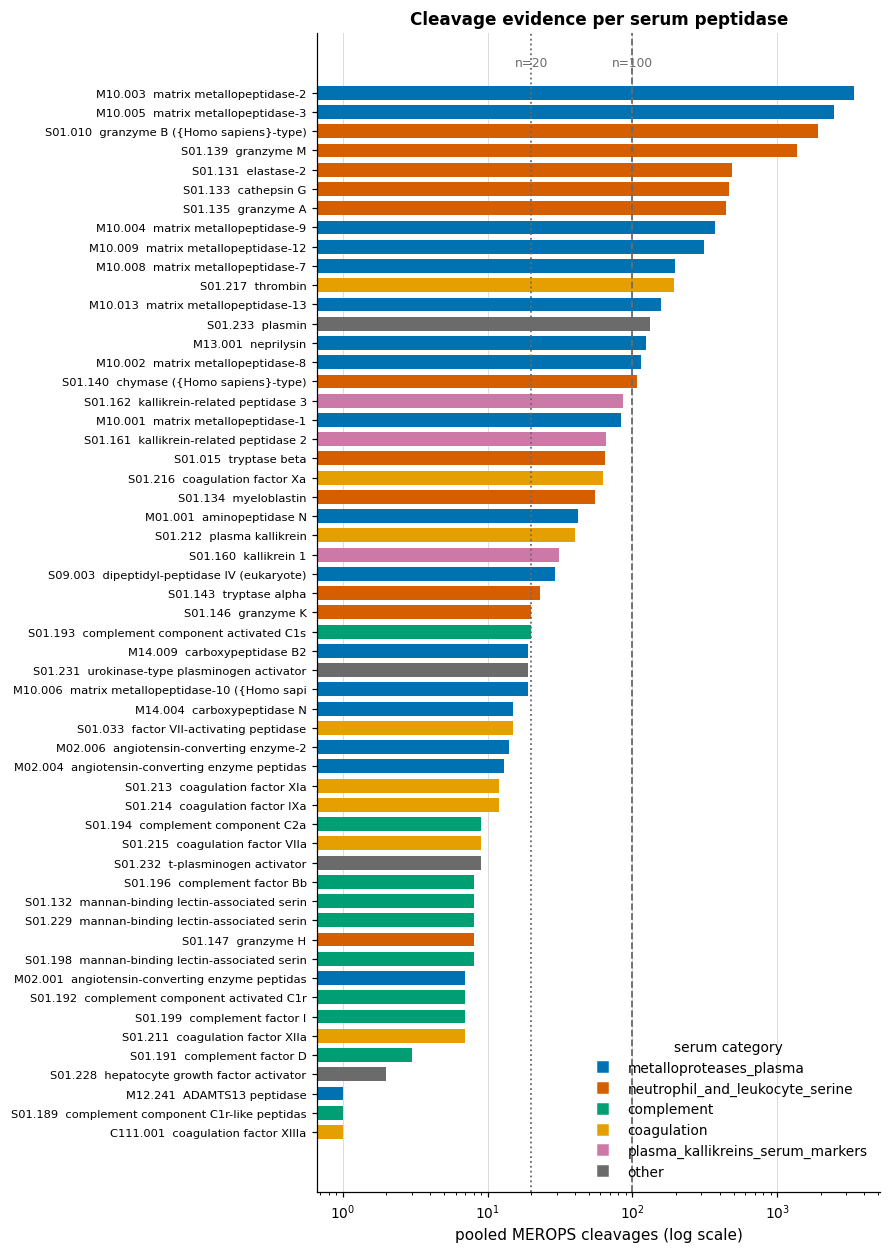

In [32]:
## Group the panel's serum categories into the fixed colour slots
category_sizes = panel["serum_category"].value_counts()
major_categories = list(category_sizes.index[: len(common.CATEGORICAL_COLORS) - 1])
category_color = {name: common.CATEGORICAL_COLORS[i] for i, name in enumerate(major_categories)}
panel["category_group"] = panel["serum_category"].where(
    panel["serum_category"].isin(major_categories), "other"
)
category_color["other"] = common.NEUTRAL

ordered = panel.sort_values("n_cleavages", ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.2, 11.5))
ax.barh(
    ordered.index,
    ordered["n_cleavages"],
    color=[category_color[group] for group in ordered["category_group"]],
    height=0.72,
)
ax.set_yticks(ordered.index)
ax.set_yticklabels([f"{row.code}  {row['name'][:38]}" for _, row in ordered.iterrows()], fontsize=7.5)
ax.set_xscale("log")
ax.set_xlabel("pooled MEROPS cleavages (log scale)")
ax.set_title("Cleavage evidence per serum peptidase")
ax.grid(axis="y", visible=False)
for threshold, style in [(20, ":"), (100, "--")]:
    ax.axvline(threshold, color=common.NEUTRAL, linestyle=style, linewidth=1.2)
    ax.text(threshold, len(ordered) + 0.4, f"n={threshold}", ha="center", fontsize=8, color=common.NEUTRAL)
handles = [plt.Line2D([], [], marker="s", linestyle="", color=color, label=name) for name, color in category_color.items()]
ax.legend(handles=handles, loc="lower right", title="serum category", title_fontsize=9)
fig.tight_layout()
plt.show()

**Provenance**

MEROPS *Substrate_search* 2023 supplies `data/merops/35_human_serum/codes.json` and `matrices_counts.npy`; `0_01` loads them through `load_protease_panel` and `load_panel_metadata` in `src/pep_compass/optimization/components/helpers/proteolysis/specificity.py`. The unit of `n_cleavages` is one literature-reported cleavage assigned to one MEROPS code, summed over natural and synthetic substrates, not one substrate or a rate measurement. The panel contains 55 code rows in `results/0_01_merops_matrices.csv`; entries without reported cuts are absent rather than zero rows. The plotted category counts aggregate these code rows by `serum_category`; `C111.001` remains visible here and is excluded from hydrolysis by `assets/scripts/downloads/serum_proteolysis_calibration/build_serum_manifest.py`. Check individual codes and counts in `codes.json` and the corresponding per-code CSV in `data/merops/35_human_serum/`; the local background article is `report/articles/2009_11_02_Rawlings_A_large_and_accurate_collection_of_peptidase_cleavages_in_the_MEROPS_database.pdf`.

> **Caveat.** No script in this repository reconstructs the MEROPS count or log-probability tensors from *Substrate_search*. The binary matrices therefore cannot be regenerated from the checked-in acquisition code. `data/merops/README.md` calls the log-probability smoothing Laplace (α = 1), whereas the numerical matrix and analysis use α = 0.5; see `log_probability_matrix` in `specificity.py`. Neither cleavage counts nor the heat map establish serum cleavage rates.


## Observation depth per subsite

A cleavage contributes to a subsite only when the substrate extends that far,
so `n_cleavages` is an upper bound on the depth of any individual subsite. The
window score sums over all eight subsites irrespective of how often each was
observed, which makes the per-subsite depth the relevant quantity.

The left panel shows the distribution across proteases of subsite depth divided by the pooled cleavage count, separately for P4–P4′. The right panel compares pooled cleavages (x) with mean observed depth across the eight subsites (y) for each code; colour shows mean relative coverage. The dotted diagonal is complete positional coverage, so points below it have missing subsite observations. The mean is a coverage summary; the shallowest-subsite depth remains a separate diagnostic in `results/0_01_merops_matrices.csv`.


In [33]:
subsite_depth = counts.sum(axis=-1)  # (N, P)
depth_frame = pd.DataFrame(subsite_depth, columns=list(MEROPS_SUBSITES))
depth_frame.insert(0, "code", codes)
depth_frame["n_cleavages"] = panel["n_cleavages"].to_numpy()
depth_frame["min_subsite_depth"] = subsite_depth.min(axis=1)
depth_frame["median_subsite_depth"] = np.median(subsite_depth, axis=1)

pooled = panel["n_cleavages"].to_numpy(dtype=float)  # (N,)
if np.any(pooled <= 0):
    raise ValueError("All MEROPS panel entries must have at least one recorded cleavage.")

relative_depth = subsite_depth / pooled[:, None]  # (N, P)
depth_frame["mean_subsite_depth"] = subsite_depth.mean(axis=1)
depth_frame["mean_relative_coverage"] = relative_depth.mean(axis=1)
depth_frame["mean_missing_depth"] = pooled - depth_frame["mean_subsite_depth"]
print("median fraction of pooled cleavages observed at each subsite:")
print(
    pd.Series(np.median(relative_depth, axis=0), index=list(MEROPS_SUBSITES)).round(3).to_string()
)
print()
print(
    f"peptidases whose shallowest subsite holds < 10 observations: "
    f"{int((depth_frame['min_subsite_depth'] < 10).sum())} / {len(depth_frame)}"
)

median fraction of pooled cleavages observed at each subsite:
P4     0.846
P3     0.935
P2     0.992
P1     1.000
P1p    0.900
P2p    0.867
P3p    0.802
P4p    0.756

peptidases whose shallowest subsite holds < 10 observations: 24 / 55


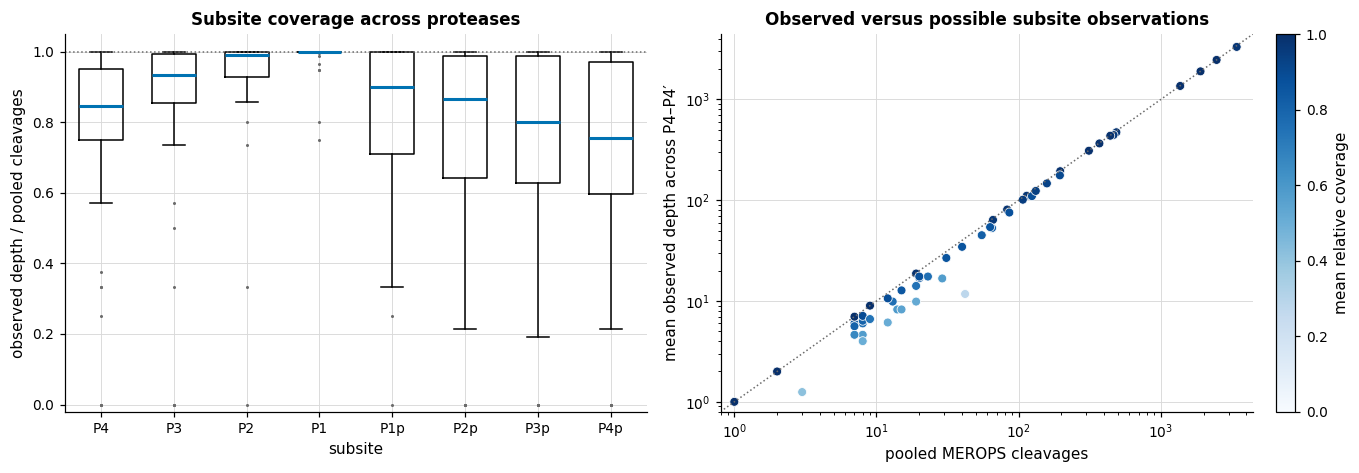

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
positions = np.arange(len(MEROPS_SUBSITES))
ax.boxplot(
    [relative_depth[:, i] for i in positions],
    positions=positions,
    widths=0.6,
    medianprops={"color": common.CATEGORICAL_COLORS[0], "linewidth": 2},
    flierprops={"marker": ".", "markersize": 4, "markerfacecolor": common.NEUTRAL, "markeredgecolor": "none"},
)
ax.set_xticks(positions)
ax.set_xticklabels(MEROPS_SUBSITES)
ax.set_ylim(-0.02, 1.05)
ax.set_ylabel("observed depth / pooled cleavages")
ax.set_xlabel("subsite")
ax.set_title("Subsite coverage across proteases")
ax.axhline(1.0, color=common.NEUTRAL, linewidth=1.0, linestyle=":")

ax = axes[1]
scatter = ax.scatter(
    pooled,
    depth_frame["mean_subsite_depth"],
    c=depth_frame["mean_relative_coverage"],
    cmap=common.SEQUENTIAL_CMAP,
    vmin=0.0,
    vmax=1.0,
    s=34,
    edgecolor="white",
    linewidth=0.5,
)
limits = [max(0.8, float(pooled.min()) * 0.8), max(float(pooled.max()), 1.0) * 1.3]
ax.plot(limits, limits, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*limits)
ax.set_ylim(*limits)
ax.set_xlabel("pooled MEROPS cleavages")
ax.set_ylabel("mean observed depth across P4–P4′")
ax.set_title("Observed versus possible subsite observations")
colorbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("mean relative coverage")
fig.tight_layout()
plt.show()

## Divergence of each subsite from the substrate composition

### Definition

For a subsite with smoothed residue distribution $p$ and reference
distribution $q$, the metric is the Kullback-Leibler divergence in bits,

$$\mathrm{IC}(p \| q) = \sum_a p_a \log_2 \frac{p_a}{q_a}.$$

### Choice of the reference distribution

$q$ defines what the subsite is compared against. The classical sequence-logo
form $\log_2 20 - H(p)$ is the special case $q_a = 1/20$, which asserts that
every residue is equally likely to occupy a subsite. No proteome satisfies
this: in the human reference proteome leucine is 8.2 times more frequent than
tryptophan. Under a uniform reference a subsite that only reproduces the
composition of the substrate pool is reported as specific, and every reported
value carries a constant offset of $D_{\mathrm{KL}}(q_{\text{human}} \| u) =
0.145$ bits.

The reference used here is the residue composition of the reviewed human
reference proteome (UniProt UP000005640, 20 416 sequences, 11.4 million
residues). MEROPS substrates are predominantly human or human-derived
sequences, so this is the composition a subsite shows in the absence of any
preference.

### Sampling floor and window null

The heat map uses a conditional sampling floor: for each MEROPS subsite, the
null draws the number of residues actually observed at that subsite from $q$.
Its excess is therefore a per-subsite contrast at the recorded depth.

The second panel asks a different question: what divergence would an entire
synthetic cleavage dataset show after $n$ cleavage windows? First count the
lengths of the unique DBAASP peptides used as the scoring-probe population.
For each of $n$ events, draw one length from that empirical frequency table,
choose one of its internal bonds uniformly, and retain only P4–P4′ positions
that lie inside the peptide. At each available position draw a residue from
$q$, aggregate the resulting counts, apply the same Jeffreys smoothing as the
MEROPS matrices, and average the eight subsite divergences. The implementation
batches residue draws by subsite; this is distributionally equivalent to drawing
them separately within each window under the stated independent-residue null.

At each $n$, repeat the entire dataset simulation 600 times. The line is the
median of those 600 mean divergences and the band covers their 5th–95th
percentiles. Each observed point is one MEROPS peptidase: its x-coordinate is
its pooled number of recorded cleavages, and its y-coordinate is the mean of
its eight observed subsite divergences. Thus $n=10$ means **ten generated
cleavage windows in each replicate**; 600 is the number of replicate datasets,
not a lower bound on $n$ or a subsite count. The replicate-level values are
saved in `results/0_01_window_null_replicates.csv`.

### Limitations

The conditional floor is not monotone in depth. The Jeffreys prior of the distributed
matrices pulls a very small sample towards a uniform distribution, so the
excess over the floor is not comparable across widely different sample sizes,
and `n_cleavages` remains the gate at the bottom of the panel.

MEROPS does not provide the source substrate lengths or cleavage-site
locations behind its pooled matrices. The DBAASP peptide lengths and uniform
bond choice are therefore an explicit proxy for a window-level null, not a
reconstruction of MEROPS events or a calibrated MEROPS p-value. The two panels
use different null models; their vertical differences should not be equated.

The smoothing prior is left unchanged. It is the prior that produced the
distributed `matrices_logprob.npy`, and the audit measures the matrix the model
consumes rather than a differently estimated one.

In [39]:
observed_ic, null_ic, excess_ic = information_content_excess(
    counts, n_samples=N_SUBSITE_NULL_SAMPLES, seed=SEED, background=human_background
)

ic_frame = pd.DataFrame(
    {
        "code": codes,
        "n_cleavages": panel["n_cleavages"].to_numpy(),
        "mean_divergence": observed_ic.mean(axis=1),
        "mean_null_divergence": null_ic.mean(axis=1),
        "mean_divergence_excess": excess_ic.mean(axis=1),
        "max_divergence_excess": excess_ic.max(axis=1),
    }
)
print(ic_frame.sort_values("mean_divergence_excess", ascending=False).head(10).round(3).to_string(index=False))
print()
print(
    f"peptidases whose mean divergence does not exceed the sampling floor: "
    f"{int((ic_frame['mean_divergence_excess'] <= 0).sum())} / {len(ic_frame)}"
)

# Build the empirical peptide-length distribution for the window-level null.
length_source = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset"])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
)
peptide_lengths = length_source["sequence"].str.len().to_numpy(dtype=np.int64)  # (M,)
length_frequencies = (
    pd.Series(peptide_lengths, name="length")
    .value_counts()
    .sort_index()
    .rename_axis("length")
    .rename("n_peptides")
)
print("DBAASP peptide lengths used by the window null:")
print(length_frequencies.to_string())
print(f"Unique source peptides: {len(peptide_lengths)}")

# Each grid value is the number of complete cleavage events in one null dataset.
window_sample_sizes = np.unique(
    np.r_[panel["n_cleavages"].to_numpy(dtype=np.int64), WINDOW_NULL_ANCHORS]
)  # (G,)
window_null_divergence, window_null_depths = simulate_window_null_divergence(
    window_sample_sizes,
    peptide_lengths,
    n_replicates=N_WINDOW_NULL_REPLICATES,
    seed=SEED,
    background=human_background,
)  # (G, B), (G, B, P)
window_null_replicates = pd.DataFrame(
    {
        "n_cleavage_windows": np.repeat(window_sample_sizes, N_WINDOW_NULL_REPLICATES),
        "replicate": np.tile(np.arange(N_WINDOW_NULL_REPLICATES), len(window_sample_sizes)),
        "mean_divergence_bits": window_null_divergence.ravel(),
        "mean_subsite_depth": window_null_depths.mean(axis=-1).ravel(),
    }
)
window_null_path = common.save_result(
    window_null_replicates, "0_01_window_null_replicates.csv"
)
print(f"Window-null replicates: {N_WINDOW_NULL_REPLICATES} per sample size")
print("At n=10: 10 generated cleavage windows in each replicate.")
print(f"Window-null observations saved: {window_null_path.relative_to(common.ROOT)}")


NameError: name 'N_SUBSITE_NULL_SAMPLES' is not defined

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0), gridspec_kw={"width_ratios": [1.15, 1]})

## Diverging map: zero excess is the neutral midpoint
ax = axes[0]
order = np.argsort(-panel["n_cleavages"].to_numpy())
### REMARK: The excess is one-sided in practice (a handful of slightly negative
### cells against a long positive tail), so the diverging ramp is anchored at
### zero with TwoSlopeNorm instead of symmetric limits, which would spend half
### the ramp on an empty range and flatten the real differences.
image = ax.imshow(
    excess_ic[order],
    aspect="auto",
    cmap=common.DIVERGING_CMAP,
    norm=TwoSlopeNorm(
        vmin=min(float(excess_ic.min()), -0.05),
        vcenter=0.0,
        vmax=float(excess_ic.max()),
    ),
    interpolation="nearest",
)
ax.set_xticks(range(len(MEROPS_SUBSITES)))
ax.set_xticklabels(MEROPS_SUBSITES)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{codes[i]} ({int(panel['n_cleavages'][i])})" for i in order], fontsize=6.5)
ax.set_title(r"Excess divergence: $D_{\mathrm{KL}}(p\|q) - \mathbb{E}_q[D_{\mathrm{KL}}(\tilde{p}\|q)]$")
ax.grid(visible=False)
fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.02,
    label=r"$D_{\mathrm{KL}}(p\|q) - \mathbb{E}_q[D_{\mathrm{KL}}(\tilde{p}\|q)]$ (bits)",
)

## Observed panel divergence versus simulated complete-window datasets
ax = axes[1]
null_lower, null_median, null_upper = np.quantile(
    window_null_divergence, [0.05, 0.5, 0.95], axis=1
)  # each (G,)
ax.fill_between(
    window_sample_sizes,
    null_lower,
    null_upper,
    color=common.CATEGORICAL_COLORS[1],
    alpha=0.2,
    label="window null: 5th–95th percentile across 600 datasets",
)
ax.plot(
    window_sample_sizes,
    null_median,
    color=common.CATEGORICAL_COLORS[1],
    linewidth=2,
    label="window null: median",
)
ax.scatter(
    panel["n_cleavages"],
    observed_ic.mean(axis=1),
    s=20,
    color=common.CATEGORICAL_COLORS[0],
    alpha=0.65,
    edgecolor="none",
    label="MEROPS: mean divergence across eight subsites",
)
ax.set_xscale("log")
ax.set_xlabel("n: cleavage windows per dataset (log scale)")
ax.set_ylabel(r"mean $D_{\mathrm{KL}}(p\|q)$ across P4–P4′ (bits)")
ax.set_title("Observed divergence versus window-sampling null")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## Reproducibility of the peptide ranking by bond reduction

### Procedure

The probe contains 1000 unique DBAASP peptide sequences selected with `SEED`.
For every peptide, protease and internal bond, the local score is the sum of
MEROPS log-probability minus human-proteome log-probability at the P4–P4′
positions present in that peptide. Missing positions contribute zero. Four
functions reduce the bond scores to one peptide score: `max`, `sum`, `mean`, and
`logsumexp` (unit temperature). These are the four reductions compared in the
score-to-kinetics figure; they all use the same peptide probe and MEROPS
matrices.

Each subsite count is resampled independently at its observed depth and
converted back to a log-probability matrix with the same Jeffreys prior. For
each of 32 bootstrap matrices and each reduction, Spearman's rho compares the
**ordering of the 1000 peptide scores** with their ordering under the shipped
matrix, separately for each protease. The plotted point is the median of the
32 rho values for that protease and reduction. Constant-score rankings have
undefined rho and are assigned zero. The complete replicate-level results are
saved in `results/0_01_rank_stability_replicates.csv`.

### Interpretation and downstream use

The four panels expose how stability depends on the bond reduction. The
`median_rank_stability` and `p10_rank_stability` columns retained for downstream
notebooks refer to `PRIMARY_RANK_REDUCTION`; the audit also stores explicitly
named columns for all four reductions and a `rank_reduction` label. The coarse
`merops_matrix_verdict` uses that selected reduction.

### Limitations

MEROPS supplies pooled subsite counts, not individual cleavage records, so the
bootstrap resamples subsites independently and cannot recover correlations
between neighbouring positions of one cleavage. Every internal bond is scored
for every protease; this figure does not impose enzyme-specific terminal-bond
geometry. `sum` and `logsumexp` also depend on the number of candidate bonds,
so their raw scores should not be compared across reductions. A high rho
measures ranking stability under this count bootstrap, not agreement with
measured kinetics.


In [ ]:
probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset"])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
    .sample(n=N_PROBE_PEPTIDES, random_state=SEED)
    .reset_index(drop=True)
)
probe_sequences = probe["sequence"].tolist()
print(f"probe peptides: {len(probe_sequences)} | length {probe['sequence'].str.len().min()}"
      f"-{probe['sequence'].str.len().max()}")



In [ ]:
# Resample the same MEROPS counts once for all four reductions.
replicate_matrices = bootstrap_specificity_matrices(
    counts, n_replicates=N_BOOTSTRAP, seed=SEED
)  # (B, N, P, A)
reference_scores, stability = bootstrap_bond_reduction_rank_stability(
    probe_sequences,
    log_probabilities,
    replicate_matrices,
    background=human_background,
)  # (R, I, N), (R, B, N)

if PRIMARY_RANK_REDUCTION not in BOND_REDUCTIONS:
    raise ValueError(f"Unknown primary rank reduction: {PRIMARY_RANK_REDUCTION}.")
primary_reduction_index = BOND_REDUCTIONS.index(PRIMARY_RANK_REDUCTION)

# Keep each Spearman correlation so the plotted medians can be reproduced.
stability_replicates = pd.DataFrame(
    {
        "reduction": np.repeat(BOND_REDUCTIONS, N_BOOTSTRAP * len(codes)),
        "replicate": np.tile(np.repeat(np.arange(N_BOOTSTRAP), len(codes)), len(BOND_REDUCTIONS)),
        "code": np.tile(codes, len(BOND_REDUCTIONS) * N_BOOTSTRAP),
        "n_cleavages": np.tile(panel["n_cleavages"].to_numpy(), len(BOND_REDUCTIONS) * N_BOOTSTRAP),
        "spearman_rho": stability.ravel(),
    }
)
stability_path = common.save_result(
    stability_replicates, "0_01_rank_stability_replicates.csv"
)

# One row per protease, with explicit columns for every bond reduction.
stability_frame = pd.DataFrame(
    {"code": codes, "n_cleavages": panel["n_cleavages"].to_numpy()}
)
for reduction_index, reduction in enumerate(BOND_REDUCTIONS):
    stability_frame[f"median_rank_stability_{reduction}"] = np.median(
        stability[reduction_index], axis=0
    )  # (N,)
    stability_frame[f"p10_rank_stability_{reduction}"] = np.percentile(
        stability[reduction_index], 10, axis=0
    )  # (N,)
stability_frame["median_rank_stability"] = stability_frame[
    f"median_rank_stability_{PRIMARY_RANK_REDUCTION}"
]
stability_frame["p10_rank_stability"] = stability_frame[
    f"p10_rank_stability_{PRIMARY_RANK_REDUCTION}"
]

print(f"Probe peptides: {len(probe_sequences)} | bootstrap matrices: {N_BOOTSTRAP}")
print(f"Primary reduction for the audit: {PRIMARY_RANK_REDUCTION}")
print(f"Replicate-level results: {stability_path.relative_to(common.ROOT)}")
print()
print("Median Spearman rho across proteases, by reduction:")
print(
    stability_frame[[f"median_rank_stability_{name}" for name in BOND_REDUCTIONS]]
    .median()
    .round(3)
    .to_string()
)
print()
print("Lowest primary-reduction rank stability:")
print(
    stability_frame.sort_values("median_rank_stability")
    .head(12)[["code", "n_cleavages", "median_rank_stability", "p10_rank_stability"]]
    .round(3)
    .to_string(index=False)
)


In [ ]:
# Compare the same protease-level statistic under each bond reduction.
fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.2), sharex=True, sharey=True)
for reduction_index, (ax, reduction) in enumerate(zip(axes.flat, BOND_REDUCTIONS)):
    column = f"median_rank_stability_{reduction}"
    ax.scatter(
        stability_frame["n_cleavages"],
        stability_frame[column],
        s=34,
        color=common.CATEGORICAL_COLORS[reduction_index],
        edgecolor="white",
        linewidth=0.6,
    )
    for _, row in stability_frame.nsmallest(3, column).iterrows():
        ax.annotate(
            row["code"],
            (row["n_cleavages"], row[column]),
            textcoords="offset points",
            xytext=(5, -3),
            fontsize=8,
            color=common.NEUTRAL,
        )
    for threshold in (0.9, 0.95):
        ax.axhline(threshold, color=common.NEUTRAL, linestyle=":", linewidth=1)
    ax.set_xscale("log")
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(reduction)
    ax.grid(axis="x", alpha=0.25)

for ax in axes[:, 0]:
    ax.set_ylabel("median Spearman ρ across 32 bootstraps")
for ax in axes[-1]:
    ax.set_xlabel("pooled MEROPS cleavages (log scale)")
fig.suptitle("Peptide-ranking reproducibility by bond reduction")
fig.tight_layout()
plt.show()


**Provenance**

The scoring probe comes from `data/peptides_data/peptides_mic/peptides_apex.csv`. Code cell 17 retains rows whose `dataset` contains `dbaasp`, removes duplicate `sequence` values, and draws `N_PROBE_PEPTIDES` sequences with `SEED` from the parameters cell. One saved correlation is a Spearman rank correlation across these peptide sequences for one MEROPS code, one bond reduction and one bootstrap matrix; `bootstrap_specificity_matrices` resamples subsite counts, not independent serum assays. `bootstrap_bond_reduction_rank_stability` scores masked bond log-odds and reduces each peptide over its bonds using `max`, `sum`, `mean` or `logsumexp`. The figure shows the median of 32 correlations per code and reduction, while `results/0_01_rank_stability_replicates.csv` retains all correlations. The input file's original acquisition and the number rejected at each selection step are not documented alongside this result: TODO: provenance do ustalenia. The plot tests sensitivity to MEROPS count sampling and does not validate a kinetic scale.


## Number of distinct specificity profiles

The `reduction="sum"` aggregation of `CleavagePotential` adds a contribution
from every panel entry, so entries encoding the same preference enter the sum
several times.

Redundancy is measured in two spaces. Matrix space uses the correlation of
the log-odds profiles against the reference distribution. Score space uses the
correlation of per-protease peptide scores under `PRIMARY_RANK_REDUCTION`
across the fixed probe. The selected reduction is recorded in the audit because
distinct-profile counts depend on this choice.


In [ ]:
reference_peptide_scores = reference_scores[primary_reduction_index]  # (I, N)
matrix_similarity = profile_similarity_matrix(log_probabilities, background=human_background)  # (N, N)
with np.errstate(invalid="ignore"):
    score_similarity = np.corrcoef(reference_peptide_scores.T)  # (N, N)
score_similarity = np.nan_to_num(score_similarity, nan=0.0)

matrix_labels = cluster_profiles(matrix_similarity, threshold=REDUNDANCY_THRESHOLD)
score_labels = cluster_profiles(score_similarity, threshold=REDUNDANCY_THRESHOLD)
print(
    f"distinct profiles at r >= {REDUNDANCY_THRESHOLD}: "
    f"{len(np.unique(matrix_labels))} (matrix space), "
    f"{len(np.unique(score_labels))} (score space), out of {len(codes)} entries"
)

redundant_groups = (
    pd.DataFrame({"code": codes, "cluster": score_labels})
    .groupby("cluster")["code"]
    .apply(list)
)
for cluster, members in redundant_groups.items():
    if len(members) > 1:
        print(f"  score-space cluster {cluster}: {', '.join(members)}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 6.0))
cluster_order = np.argsort(score_labels, kind="stable")
for ax, similarity, title in [
    (axes[0], matrix_similarity, "Specificity-profile correlation"),
    (axes[1], score_similarity, "Probe-score correlation"),
]:
    image = ax.imshow(
        similarity[np.ix_(cluster_order, cluster_order)],
        cmap=common.DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_xticks(range(len(codes)))
    ax.set_xticklabels([codes[i] for i in cluster_order], rotation=90, fontsize=5.5)
    ax.set_yticks(range(len(codes)))
    ax.set_yticklabels([codes[i] for i in cluster_order], fontsize=5.5)
    ax.set_title(title)
    ax.grid(visible=False)
    fig.colorbar(image, ax=ax, fraction=0.045, pad=0.02, label="Pearson r")
fig.tight_layout()
plt.show()

## Audit table

One row per panel entry with its evidence depth, divergence excess, score
reproducibility under all four bond reductions and the selected score-space
redundancy group. `rank_reduction` identifies the reduction behind the legacy
`median_rank_stability` and `p10_rank_stability` columns. The
`merops_matrix_verdict` column combines the cleavage count with that selected
score reproducibility and is consumed by
`0_14_dataset_definition.ipynb`.

In [ ]:
stability_columns = [
    "code", "median_rank_stability", "p10_rank_stability",
    *[f"median_rank_stability_{name}" for name in BOND_REDUCTIONS],
    *[f"p10_rank_stability_{name}" for name in BOND_REDUCTIONS],
]
audit = (
    panel[["code", "name", "serum_category", "n_cleavages"]]
    .merge(depth_frame[["code", "min_subsite_depth", "median_subsite_depth"]], on="code")
    .merge(
        ic_frame[["code", "mean_divergence", "mean_null_divergence", "mean_divergence_excess"]],
        on="code",
    )
    .merge(stability_frame[stability_columns], on="code")
)
audit["rank_reduction"] = PRIMARY_RANK_REDUCTION
audit["matrix_cluster"] = matrix_labels
audit["score_cluster"] = score_labels
audit["score_cluster_size"] = audit["score_cluster"].map(audit["score_cluster"].value_counts())

## Coarse verdict on whether the matrix can be scored at all
audit["merops_matrix_verdict"] = np.select(
    [
        (audit["n_cleavages"] >= 100) & (audit["median_rank_stability"] >= 0.95),
        (audit["n_cleavages"] >= 20) & (audit["median_rank_stability"] >= 0.90),
        audit["n_cleavages"] >= 5,
    ],
    ["well_determined", "usable", "weak"],
    default="uninformative",
)
print(audit["merops_matrix_verdict"].value_counts().to_string())

destination = common.save_result(audit.round(4), "0_01_merops_matrices.csv")
print(f"\nwritten: {destination.relative_to(common.ROOT)}")
audit.sort_values("n_cleavages", ascending=False).head(15).round(3)